In [1]:
# start 8 worker nodes
import ipyparallel as ipp
cluster = ipp.Cluster(n=8)
client = cluster.start_and_connect_sync()
client.ids

Starting 8 engines with <class 'ipyparallel.cluster.launcher.LocalEngineSetLauncher'>


  0%|          | 0/8 [00:00<?, ?engine/s]

[0, 1, 2, 3, 4, 5, 6, 7]

In [2]:
# Set env variables

MASTER_ADDR = '127.0.0.1'
MASTER_PORT = 29701

def _setup(rank, world_size, master, port):
    import os

    os.environ["MASTER_ADDR"] = master
    os.environ["MASTER_PORT"] = str(port)
    os.environ["WORLD_SIZE"] = str(world_size)
    os.environ["RANK"] = str(rank)

    os.environ["LOCAL_WORLD_SIZE"] = str(world_size)
    os.environ["LOCAL_RANK"] = str(rank)
    os.environ["NODE_RANK"] = "0"

    return f"{rank} is ready for action"

futures = []
for i in range(len(client.ids)):
    futures.append(client[i].apply_async(_setup, i, len(client.ids), MASTER_ADDR, MASTER_PORT))

for f in futures:
    print(f.result())

0 is ready for action
1 is ready for action
2 is ready for action
3 is ready for action
4 is ready for action
5 is ready for action
6 is ready for action
7 is ready for action


In [3]:
%%px
# Imports + torch set up (note px magix runs the code on the worker nodes)

import os
import json
import torch
import torch.distributed as distr

import bv2.simple_fsdp
import bv2.utils as u

from bv2.train import summary_table, is_decay, load_ckpt
from bv2.model import SimpleTransformer
from bv2.config.synth_ocr import get_config
from bv2.simple_data import from_config as data_from_config

from functools import partial

from torch.profiler import record_function
import torch.distributed.checkpoint as dcp
import torch.distributed.checkpoint.state_dict as dcpsd

if distr.is_initialized():
    pass
else:
    device = torch.device(f"cuda:{os.environ["RANK"]}")
    torch.cuda.set_device(device)
    distr.init_process_group(
        "cpu:gloo,cuda:nccl",
        rank=int(os.environ["RANK"]), world_size=int(os.environ["WORLD_SIZE"]),
        device_id=device
    )
    mesh = distr.device_mesh.init_device_mesh(
        "cuda",
        mesh_shape=(int(os.environ["WORLD_SIZE"]),),
        mesh_dim_names=("dp",),  # Add "tp" for 2d parallel
    ) 

%px:   0%|          | 0/8 [00:00<?, ?tasks/s]

[stdout:2] [Gloo] Rank 2 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7


[stdout:1] [Gloo] Rank 1 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7


[stderr:1] [W1204 09:28:28.849204961 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())
[W1204 09:28:31.531781515 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())


[stdout:0] [Gloo] Rank 0 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7
NCCL version 2.27.5+cuda12.9


...

[stderr:5] [W1204 09:28:28.849759350 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())
[W1204 09:28:31.531498561 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())


[stderr:4] [W1204 09:28:28.849662318 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())
[W1204 09:28:31.527729628 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())


[stderr:2] [W1204 09:28:28.849256861 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())
[W1204 09:28:31.531141525 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())


[stdout:7] [Gloo] Rank 7 is connected to 7 peer ranks. Expected number of connected peer ranks is : 7


[stderr:7] [W1204 09:28:28.849815581 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())
[W1204 09:28:31.528827476 Utils.hpp:137] Warning: Environment variable TORCH_NCCL_TRACE_BUFFER_SIZE is deprecated; use TORCH_FR_BUFFER_SIZE instead (function operator())


In [4]:
%%px
# set up model and optim

c = get_config().finalize()
ds = data_from_config({'seed': (c.seed, "dataset"), **c.data.to_dict()})

with torch.device("meta"):
    model = SimpleTransformer(
        **{"vocab": ds.vocab_size(), **c.model.to_dict()},
    )

# This wraps all param properties with a shard/gather code.
model = bv2.simple_fsdp.data_parallel(
    model,
    mesh,
    mode="fully_shard",  # Or: "replicate"
    # Only do FSDP's "remat" (of params/comms) if we don't already cover that ourselves.
    need_ac=not c.model.get("remat", True),
    mp_policy=bv2.simple_fsdp.MixedPrecisionPolicy(
        param_dtype=torch.bfloat16, reduce_dtype=torch.bfloat16
    ),
    min_bytes=1024 * 1024,  # Don't shard params that are less than 1MiB
)

# Allocate buffers and sharded parameters on GPU
model.to_empty(device=device)

with torch.no_grad():
    with bv2.simple_fsdp.disable_data_parallel():  # super important, or nothing happens.
        model.init_weights(u.rng_torch(c.seed, "param_init", device=device))

optim = torch.optim.AdamW(model.parameters(), betas=(c.get("beta1", 0.9), c.get("beta2", 0.999)), lr=0.0, fused=True)
decay_params = [p for n, p in model.named_parameters() if is_decay(n)]

@record_function("fwd_and_bwd")
@u.suppress_warnings("`isinstance(treespec, LeafSpec)` is deprecated", FutureWarning)
@partial(torch.compile, dynamic=False)
def _fwd_and_bwd_step(weight_decay, *a, **kw):
    loss, extras = model(*a, mode="loss and bwd", **kw)
    optim.step()
    if weight_decay:
        with torch.no_grad():
            for param in decay_params:
                param.mul_(1.0 - weight_decay)
    return loss, extras
        
if distr.get_rank() == 0:
    summary_table(model, stats=c.get("param_stats", False))

[stderr:1] [rank1]:W1204 09:28:48.693000 3439526 /storage/home/pplx/.conda/envs/gpu/lib/python3.12/site-packages/torch/distributed/tensor/_random.py:208] DTensor is synchronizing RNG states of every rank with the state from rank 0. This behavior is deprecated. Please call `torch.manual_seed()` on every rank that participates in SPMD DTensor Operations with the same seed. If using Pipeline Parallelism, each pipeling state would use a different seed, but all ranks belonging to one pipeline stage would use the same seed.


[stderr:4] [rank4]:W1204 09:28:48.693000 3439532 /storage/home/pplx/.conda/envs/gpu/lib/python3.12/site-packages/torch/distributed/tensor/_random.py:208] DTensor is synchronizing RNG states of every rank with the state from rank 0. This behavior is deprecated. Please call `torch.manual_seed()` on every rank that participates in SPMD DTensor Operations with the same seed. If using Pipeline Parallelism, each pipeling state would use a different seed, but all ranks belonging to one pipeline stage would use the same seed.


[stderr:2] [rank2]:W1204 09:28:48.693000 3439528 /storage/home/pplx/.conda/envs/gpu/lib/python3.12/site-packages/torch/distributed/tensor/_random.py:208] DTensor is synchronizing RNG states of every rank with the state from rank 0. This behavior is deprecated. Please call `torch.manual_seed()` on every rank that participates in SPMD DTensor Operations with the same seed. If using Pipeline Parallelism, each pipeling state would use a different seed, but all ranks belonging to one pipeline stage would use the same seed.


[stderr:5] [rank5]:W1204 09:28:48.693000 3439537 /storage/home/pplx/.conda/envs/gpu/lib/python3.12/site-packages/torch/distributed/tensor/_random.py:208] DTensor is synchronizing RNG states of every rank with the state from rank 0. This behavior is deprecated. Please call `torch.manual_seed()` on every rank that participates in SPMD DTensor Operations with the same seed. If using Pipeline Parallelism, each pipeling state would use a different seed, but all ranks belonging to one pipeline stage would use the same seed.


[stderr:7] [rank7]:W1204 09:28:48.693000 3439547 /storage/home/pplx/.conda/envs/gpu/lib/python3.12/site-packages/torch/distributed/tensor/_random.py:208] DTensor is synchronizing RNG states of every rank with the state from rank 0. This behavior is deprecated. Please call `torch.manual_seed()` on every rank that participates in SPMD DTensor Operations with the same seed. If using Pipeline Parallelism, each pipeling state would use a different seed, but all ranks belonging to one pipeline stage would use the same seed.


[stderr:6] [rank6]:W1204 09:28:48.694000 3439542 /storage/home/pplx/.conda/envs/gpu/lib/python3.12/site-packages/torch/distributed/tensor/_random.py:208] DTensor is synchronizing RNG states of every rank with the state from rank 0. This behavior is deprecated. Please call `torch.manual_seed()` on every rank that participates in SPMD DTensor Operations with the same seed. If using Pipeline Parallelism, each pipeling state would use a different seed, but all ranks belonging to one pipeline stage would use the same seed.


[stderr:3] [rank3]:W1204 09:28:48.694000 3439530 /storage/home/pplx/.conda/envs/gpu/lib/python3.12/site-packages/torch/distributed/tensor/_random.py:208] DTensor is synchronizing RNG states of every rank with the state from rank 0. This behavior is deprecated. Please call `torch.manual_seed()` on every rank that participates in SPMD DTensor Operations with the same seed. If using Pipeline Parallelism, each pipeling state would use a different seed, but all ranks belonging to one pipeline stage would use the same seed.


[output:0]

───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  name                         shape           dtype       params         placement    local shape   weight decay  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  img_emb.proj.weig…     (2048, 768)         float32    1'572'864   (Shard(dim=0),)     (256, 768)           True  
  img_emb.ln.weight          (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  img_emb.ln.bias            (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  img_emb.ape_ln.we…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  img_emb.ape_ln.bi…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  txt_emb.pe_scale                ()         float32            1    (Replicate(),)             ()          False  
  txt_emb.emb.weight   (10003, 2048)         float32   20'486'144   (Shard(dim=0),)   (1251, 2048)          False  
  txt_unemb.head.we…   (10003, 2048)         float32   20'486'144   (Shard(dim=0),)   (1251, 2048)           True  
  txt_unemb.head.bi…        (10003,)         float32       10'003    (Replicate(),)       (10003,)          False  
  blocks.0.att_ln.w…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.0.att_ln.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.0.mlp_ln.w…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.0.mlp_ln.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.0.att.q.we…    (2048, 2048)         float32    4'194'304   (Shard(dim=0),)    (256, 2048)           True  
  blocks.0.att.k.we…     (512, 2048)         float32    1'048'576   (Shard(dim=0),)     (64, 2048)           True  
  blocks.0.att.v.we…     (512, 2048)         float32    1'048'576   (Shard(dim=0),)     (64, 2048)           True  
  blocks.0.att.o.we…    (2048, 2048)         float32    4'194'304   (Shard(dim=0),)    (256, 2048)           True  
  blocks.0.mlp.l1.w…    (8192, 2048)         float32   16'777'216   (Shard(dim=0),)   (1024, 2048)           True  
  blocks.0.mlp.l1.b…         (8192,)         float32        8'192    (Replicate(),)        (8192,)          False  
  blocks.0.mlp.l2.w…    (2048, 8192)         float32   16'777'216   (Shard(dim=0),)    (256, 8192)           True  
  blocks.0.mlp.l2.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.att_ln.w…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.att_ln.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.mlp_ln.w…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.mlp_ln.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.att.q.we…    (2048, 2048)         float32    4'194'304   (Shard(dim=0),)    (256, 2048)           True  
  blocks.1.att.k.we…     (512, 2048)         float32    1'048'576   (Shard(dim=0),)     (64, 2048)           True  
  blocks.1.att.v.we…     (512, 2048)         float32    1'048'576   (Shard(dim=0),)     (64, 2048)           True  
  blocks.1.att.o.we…    (2048, 2048)         float32    4'194'304   (Shard(dim=0),)    (256, 2048)           True  
  blocks.1.mlp.l1.w…    (8192, 2048)         float32   16'777'216   (Shard(dim=0),)   (1024, 2048)           True  
  blocks.1.mlp.l1.b…         (8192,)         float32        8'192    (Replicate(),)        (8192,)          False  
  blocks.1.mlp.l2.w…    (2048, 8192)         float32   16

In [44]:
%%px --local
# local flag also saves vars in the local kernel instance 

workdir = "/checkpoint/rigi/bv2/workdirs/1203_131839/synth_ocr_1203_131839_0-baseline"
resume_step = 7621
ckpt_path = f"{workdir}/ckpt-{resume_step:06d}"

In [49]:
%%px
# Now we can load a ckpt

class ModelState(dcp.stateful.Stateful):
    def __init__(self, model):
        self.model = model
        self.opts = dcpsd.StateDictOptions(cpu_offload=True)

    def state_dict(self):  # "Saving"
        return dcpsd.get_model_state_dict(self.model, options=self.opts)

    def load_state_dict(self, sd):
        dcpsd.set_model_state_dict(self.model, sd)


class OptimState(dcp.stateful.Stateful):
    def __init__(self, model, optim):
        self.model = model
        self.optim = optim
        self.opts = dcpsd.StateDictOptions(cpu_offload=True)

    def state_dict(self):  # "Saving"
        return dcpsd.get_optimizer_state_dict(self.model, self.optim, options=self.opts)

    def load_state_dict(self, sd):
        dcpsd.set_optimizer_state_dict(self.model, self.optim, sd)

dcp.load(
    {"model": ModelState(model), "optim": OptimState(model, optim)},
    checkpoint_id=ckpt_path,
    planner=dcp.default_planner.DefaultLoadPlanner(allow_partial_load=True),
)

with open(os.path.join(ckpt_path, "extras.json"), "r") as f:
    extras = json.load(f)
    if len(extras) != (w := distr.get_world_size()):
        raise RuntimeError(f"World size changed: {len(extras)} != {w}")
    extras = extras[distr.get_rank()]

    resumed_ep, resumed_i = (
        extras["data"]["ep"], extras["data"]["i"])
    first_step, tokens_seen, examples_seen = (
        extras["step"], extras["tokens_seen"], extras["examples_seen"])

if distr.get_rank() == 0:
    summary_table(model, stats=c.get("param_stats", False))

%px:   0%|          | 0/8 [00:00<?, ?tasks/s]

[output:0]

───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  name                         shape           dtype       params         placement    local shape   weight decay  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  img_emb.proj.weig…     (2048, 768)         float32    1'572'864   (Shard(dim=0),)     (256, 768)           True  
  img_emb.ln.weight          (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  img_emb.ln.bias            (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  img_emb.ape_ln.we…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  img_emb.ape_ln.bi…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  txt_emb.pe_scale                ()         float32            1    (Replicate(),)             ()          False  
  txt_emb.emb.weight   (10003, 2048)         float32   20'486'144   (Shard(dim=0),)   (1251, 2048)          False  
  txt_unemb.head.we…   (10003, 2048)         float32   20'486'144   (Shard(dim=0),)   (1251, 2048)           True  
  txt_unemb.head.bi…        (10003,)         float32       10'003    (Replicate(),)       (10003,)          False  
  blocks.0.att_ln.w…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.0.att_ln.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.0.mlp_ln.w…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.0.mlp_ln.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.0.att.q.we…    (2048, 2048)         float32    4'194'304   (Shard(dim=0),)    (256, 2048)           True  
  blocks.0.att.k.we…     (512, 2048)         float32    1'048'576   (Shard(dim=0),)     (64, 2048)           True  
  blocks.0.att.v.we…     (512, 2048)         float32    1'048'576   (Shard(dim=0),)     (64, 2048)           True  
  blocks.0.att.o.we…    (2048, 2048)         float32    4'194'304   (Shard(dim=0),)    (256, 2048)           True  
  blocks.0.mlp.l1.w…    (8192, 2048)         float32   16'777'216   (Shard(dim=0),)   (1024, 2048)           True  
  blocks.0.mlp.l1.b…         (8192,)         float32        8'192    (Replicate(),)        (8192,)          False  
  blocks.0.mlp.l2.w…    (2048, 8192)         float32   16'777'216   (Shard(dim=0),)    (256, 8192)           True  
  blocks.0.mlp.l2.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.att_ln.w…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.att_ln.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.mlp_ln.w…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.mlp_ln.b…         (2048,)         float32        2'048    (Replicate(),)        (2048,)          False  
  blocks.1.att.q.we…    (2048, 2048)         float32    4'194'304   (Shard(dim=0),)    (256, 2048)           True  
  blocks.1.att.k.we…     (512, 2048)         float32    1'048'576   (Shard(dim=0),)     (64, 2048)           True  
  blocks.1.att.v.we…     (512, 2048)         float32    1'048'576   (Shard(dim=0),)     (64, 2048)           True  
  blocks.1.att.o.we…    (2048, 2048)         float32    4'194'304   (Shard(dim=0),)    (256, 2048)           True  
  blocks.1.mlp.l1.w…    (8192, 2048)         float32   16'777'216   (Shard(dim=0),)   (1024, 2048)           True  
  blocks.1.mlp.l1.b…         (8192,)         float32        8'192    (Replicate(),)        (8192,)          False  
  blocks.1.mlp.l2.w…    (2048, 8192)         float32   16

In [50]:
%%px
# let's run 20 train steps

from bv2.train import global_schedule, set_lr_, global_reduce
from pprint import pprint

step = first_step

g = bv2.simple_data.data_iter(
            ds, seed=(c.seed, "data_iter"),
            device=device, rank=distr.get_rank(), world_size=distr.get_world_size(),
            resumed_ep=resumed_ep, resumed_i=resumed_i,
            **c.iter.to_dict(),
        )

losses = {}
for i in range(20):
    sched = global_schedule(
        step=step,
        total_steps=c.nsteps,
        warmup_steps=c.warmup_nsteps,
    )
    lr = sched * c.lr
    set_lr_(optim, lr)
    model.zero_grad(set_to_none=True)

    data = next(g)
    local_loss, extras = _fwd_and_bwd_step(
        c.wd * sched,
        data["tokens"],
        data["flex_masks"],
        data["loss_weights"],
        data["iseq"],
    )
    torch.cuda.synchronize()
    distr.barrier()
    
    loss = sum(u.all_gather_object(local_loss.cpu().item()))
    losses[step] = loss

    if distr.get_rank() == 0:
        print(f"{step=}, {loss=}")

    step += 1

%px:   0%|          | 0/8 [00:00<?, ?tasks/s]

[stdout:0] step=7621, loss=0.07812064071185887
step=7622, loss=0.07301313173957169
step=7623, loss=0.03539718873798847
step=7624, loss=0.11315166135318577
step=7625, loss=0.08176660584285855
step=7626, loss=0.20839149388484657
step=7627, loss=0.39665718749165535
step=7628, loss=0.1627943548373878
step=7629, loss=0.5630497522652149
step=7630, loss=1.5619700849056244
step=7631, loss=2.4893450886011124
step=7632, loss=2.0103461742401123
step=7633, loss=2.5761410295963287
step=7634, loss=3.280645340681076
step=7635, loss=3.413660228252411
step=7636, loss=3.483914017677307
step=7637, loss=3.4665443003177643
step=7638, loss=3.4199607968330383
step=7639, loss=3.5835421085357666
step=7640, loss=3.574130058288574


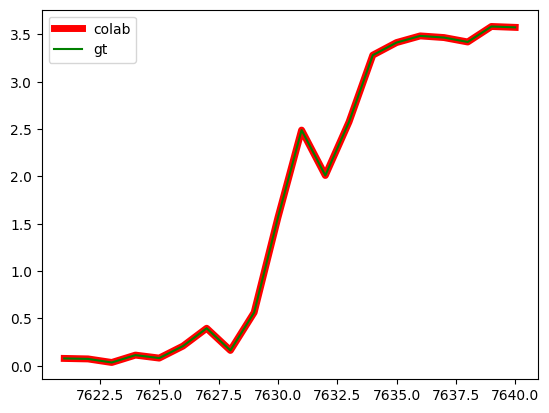

In [53]:
# now let's plot stuff

# get loss from the worker
losses = client[0].apply(lambda: losses).result()

# get "gt" losses from logs
import json
gt_losses = {}
with open(f"{workdir}/metrics.jsonl") as f:
    for m in [json.loads(line) for line in f]:
        step = m.pop('step')
        gt_losses[step] = m

# Plot
import matplotlib.pyplot as plt

steps = np.sort(list(losses.keys()))

f = plt.figure()
ax = f.subplots()

ax.plot(steps, [losses[s] for s in steps], color='red', label='colab', linewidth=5)
ax.plot(steps, [gt_losses[s]["train/loss"] for s in steps], color='green', label='gt', linew)
ax.legend()